# ROUTING

In [1]:
from langchain_gigachat.chat_models import GigaChat

In [2]:
from datasets import load_dataset
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import Chroma
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser
from langchain.schema import Document

import warnings
warnings.filterwarnings("ignore")

In [3]:
import os
from dotenv import load_dotenv
load_dotenv()

api_key = os.getenv("GIGACHAT_TOKEN")

In [9]:
# !pip install wikipedia

In [4]:
os.environ["USE_TF"] = "0"
os.environ["TRANSFORMERS_NO_TF"] = "1"  

In [5]:
llm_01 = GigaChat(
    credentials=api_key,
    verify_ssl_certs=False,
    scope="GIGACHAT_API_PERS",
    temperature=0.1,
    profanity_check=False,
    model="GigaChat",
)

In [6]:
class E5MultilingualEmbeddings(HuggingFaceEmbeddings):
    def embed_query(self, text: str):
        return super().embed_query(f"query: {text}")
    def embed_documents(self, texts):
        return super().embed_documents([f"passage: {t}" for t in texts])

emb = E5MultilingualEmbeddings(
    model_name="intfloat/multilingual-e5-base",
    encode_kwargs={"normalize_embeddings": True},
)

=======================================================================================

In [10]:
# === Загрузка wiki-статей (RU) и сплиттер ===
from langchain_community.document_loaders import WikipediaLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter

spb_docs = WikipediaLoader(query="Санкт-Петербург", lang="ru", load_max_docs=1).load()
msk_docs = WikipediaLoader(query="Москва", lang="ru", load_max_docs=1).load()

splitter = RecursiveCharacterTextSplitter( 
    chunk_size=800, chunk_overlap=120,
    separators=["\n\n", "\n", ". ", "? ", "! ", " "]
)

spb_chunks = splitter.split_documents(spb_docs)
msk_chunks = splitter.split_documents(msk_docs)


In [12]:
# === Одна БД Chroma, две коллекции: spb / moscow ===
from chromadb import PersistentClient
from langchain_community.vectorstores import Chroma

client = PersistentClient(path="chroma_db") 

vs_spb = Chroma(client=client, collection_name="spb",    embedding_function=emb)
vs_msk = Chroma(client=client, collection_name="moscow", embedding_function=emb)

vs_spb.add_documents(spb_chunks)  # индекс СПб
vs_msk.add_documents(msk_chunks)  # индекс Москва

# vs_spb.persist(); vs_msk.persist() 

['4be6fad0-21ca-42d4-8ce3-7d58c2bc00eb',
 'a815f556-169d-4ea6-96d0-1235a2841766',
 '5a3a59c0-4293-46b2-b8e8-20221cc74397',
 'c79b1894-571c-4c47-b3df-36f1da9fe006',
 '89deec97-d2db-422f-a59d-c0c7f9995c50',
 'e127549a-4af9-443e-a0fa-b601587b16f8',
 'bafe86e3-4e91-42eb-8ba9-8906add08f38',
 '9e3e7437-7594-4344-873c-6fb3fe107c65',
 '0abb466c-26cc-433c-a4b8-70033a3bb555']

In [16]:
# === Router с structured_output (GigaChat): выбор коллекции 'spb' или 'moscow' ===
from typing import Literal
from langchain_core.pydantic_v1 import BaseModel, Field
from langchain_core.prompts import ChatPromptTemplate

class RouteQuery(BaseModel):
    """Куда роутить вопрос: 'spb' (Санкт-Петербург) или 'moscow' (Москва)."""
    datasource: Literal["spb", "moscow"] = Field(..., description="Выбери единственную целевую коллекцию")

structured_llm = llm_01.with_structured_output(RouteQuery)

# Промпт роутера
prompt_router = ChatPromptTemplate.from_messages([
    ("system",
     "Классифицируй пользовательский вопрос по городам. "
     "Если вопрос про Санкт-Петербург — выбери 'spb'; если про Москву — 'moscow'. "
     "Выбирай только из этих двух вариантов."),
    ("human", "{question}"),
])

# Цепочка роутера
router_chain = prompt_router | structured_llm

# Пример использования
user_q = "На каком побережье расположен Санкт-Петербург и через устье какой реки он выходит к Финскому заливу?" 
route = router_chain.invoke({"question": user_q})    # -> RouteQuery(datasource='spb')

retrievers = {
    "spb": vs_spb.as_retriever(search_kwargs={"k": 4}),     
    "moscow": vs_msk.as_retriever(search_kwargs={"k": 4}),  
}
docs = retrievers[route.datasource].invoke(user_q)         


In [17]:
def join_docs(docs):  # склейка контекста
    return "\n\n".join(getattr(d, "page_content", "").strip() for d in (docs or []))

prompt_final = ChatPromptTemplate.from_messages([
    ("system", "Отвечай на вопрос, опираясь на предоставленный контекст. "
               "Если фактов недостаточно, кратко укажи на это."),
    ("human", "Контекст:\n---\n{context}\n---\n\nВопрос: {question}\nДай ответ.")
])

final_chain = prompt_final | llm_01 | StrOutputParser()  # промпт → LLM → текст

question = user_q  
route = router_chain.invoke({"question": question})      # RouteQuery(datasource='spb'|'moscow')
docs = retrievers[route.datasource].invoke(question)     # поиск по выбранной коллекции
answer = final_chain.invoke({"context": join_docs(docs), "question": question})
answer

'Санкт-Петербург расположен на северо-западе страны на побережье Финского залива и выходит к нему через устье реки Невы.'

================================================================================================================

### Semantic routing
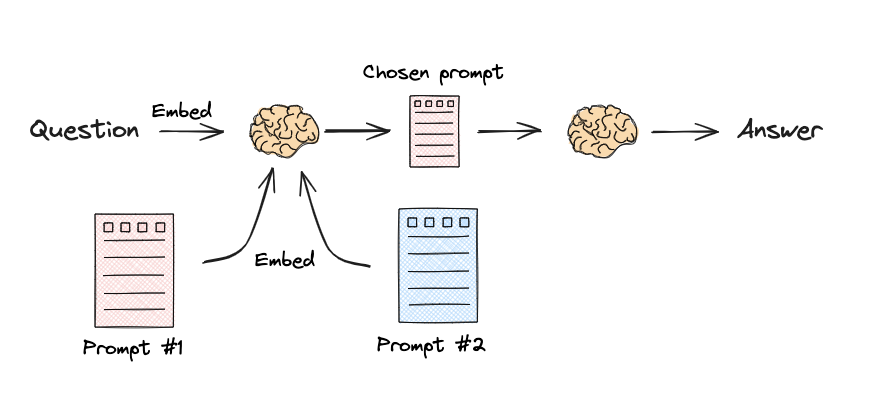

In [25]:
# === Семантический выбор промпта (E5 + GigaChat) ===
from langchain.utils.math import cosine_similarity
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnableLambda, RunnablePassthrough

physics_template = (
    "Ты — очень сильный преподаватель физики. Отвечай кратко и понятно. "
    "Если не знаешь — скажи, что не знаешь.\n\nВопрос:\n{query}"
)
math_template = (
    "Ты — отличный математик. Разбивай сложные задачи на части и решай по шагам, "
    "после чего собирай итоговый ответ.\n\nВопрос:\n{query}"
)

prompt_templates = [physics_template, math_template]
prompt_embeddings = emb.embed_documents(prompt_templates)  

from langchain_core.messages import HumanMessage

def choose_and_format(inputs):
    q = inputs["query"]                                  
    qv = emb.embed_query(q)                              
    sim = cosine_similarity([qv], prompt_embeddings)[0]
    chosen = prompt_templates[sim.argmax()]             
    return [HumanMessage(content=chosen.format(query=q))]  


chain = (
    {"query": RunnablePassthrough()}
    | RunnableLambda(choose_and_format)  # -> List[BaseMessage]
    | llm_01
    | StrOutputParser()
)

print(chain.invoke("Что такое чёрная дыра?"))

Чёрная дыра — область пространства-времени, где гравитация настолько сильна, что даже свет не способен её покинуть: любая материя и излучение, попав внутрь определённой границы (горизонта событий), уже не могут выйти обратно. Горизонт событий определяется радиусом Шварцшильда, зависящим от массы чёрной дыры. Считается, что внутри горизонта находится сингулярность — точка бесконечной плотности и кривизны пространства-времени.
